<a href="https://colab.research.google.com/github/jlaradepaz-code/Telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello se debe trabajar con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

---
## 🧩 Paso 1: Cargar y explorar

 **familiarizarte con la estructura de los tres datasets**:
En esta etapa, se valida que los archivos se carguen correctamente, paraparaconocer sus columnas y tipos de datos, y detectar posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importar las librerías  `pandas`, `seaborn`, `matplotlib.pyplot`
- Cargar los archivos CSV`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guardar los DataFrames en las variables: `plans`, `users`, `usage`.  
- Se muestran las primeras filas de cada DataFrame usando `.head()`.


In [7]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [15]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'plans.csv'

### 📂 Subir archivos CSV desde tu computadora
Ejecuta la siguiente celda para abrir el selector de archivos de tu computadora y cargar tus datasets (`plans.csv`, `users_latam.csv` y `usage.csv`). Una vez subidos, se guardarán temporalmente en el entorno actual para que tu código pueda leerlos.

In [14]:
from google.colab import files
import os

# Crear un directorio temporal si se requiere replicar la ruta exacta '/datasets/'
os.makedirs('/datasets', exist_ok=True)

print("Selecciona tus archivos CSV (plans.csv, users_latam.csv, usage.csv) desde tu computadora:")
uploaded = files.upload()

# Mover los archivos subidos al directorio '/datasets/'
for filename in uploaded.keys():
    destino = os.path.join('/datasets', filename)
    os.rename(filename, destino)
    print(f"Archivo {filename} guardado exitosamente en {destino}")

Selecciona tus archivos CSV (plans.csv, users_latam.csv, usage.csv) desde tu computadora:


Saving plans.csv to plans.csv
Saving usage.csv to usage.csv
Saving users_latam.csv to users_latam.csv
Archivo plans.csv guardado exitosamente en /datasets/plans.csv
Archivo usage.csv guardado exitosamente en /datasets/usage.csv
Archivo users_latam.csv guardado exitosamente en /datasets/users_latam.csv


### 🔄 Cargar los datasets cargados en memoria

Ejecuta esta celda para cargar de manera definitiva los archivos desde la ruta `/datasets/` en tus dataframes de pandas.

In [19]:
# Cargar los archivos que acabas de subir desde la ruta /datasets/
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

# Confirmar carga exitosa mostrando las primeras filas de cada uno
print("Plans DataFrame:")
display(plans.head(2))

print("\nUsers DataFrame:")
display(users.head(2))

print("\nUsage DataFrame:")
display(usage.head(2))

Plans DataFrame:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07



Users DataFrame:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN



Usage DataFrame:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0


In [20]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [21]:
users.head()# mostrar las primeras 5 filas de plan# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [22]:
# Asegúrate de haber ejecutado la celda donde se define: usage = pd.read_csv('/datasets/usage.csv')
usage.head()  # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisar el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usar `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [23]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [24]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [26]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [27]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Contar valores nulos por columna para cada dataset.
- Calcular la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

In [28]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())# Cantidad de valores nulos)
print(usage.isna().mean())# Proporción de valores nulos)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- se observa a partir del la instrucción "isna()"los siguientes resultados por dataset y columna:
    -dataset "plans", se omite el ánalisis como se mencionó, solo tiene dos filas, y no se detectan omisiones en sus registros.
    - dataset "users":
    - la columna "city", con 469 ceros, lo que representa un 11.72%, lo cual representa una proporción significativa en el conjunto de datos, no se pueden descartar. Tampoco sería correcto imputar sobre todo al ser esta variable del tipo "object" o categórica. Se recomienda indagar a profundidad si existen patrones o el motivo de la ausencia del dato.
    - la columna "churn",con 3524 ausentes, lo que corresponde a un 88.35% de los datos, por el contexto de esta columna para el negocio, es una cifra correcta., se ignora.
    - para el dataset "usage":
    - La columna "date" presenta 50 registros nulos, un 0.1125%, una cifra insignificante, la cual se puede imputar con la media, sin verse afectadas el resto de las opraciones y análisis.
    - la columna "duration" indica 22076 registros nulos, un 55.19%, esta variable puede contener ceros,no se realiza ningún cambio. Se propone la búsqueda de patrones para interpretar los ceros
    - La columna "lenght", 17896 registros nulos, equivalente al 44.74% del total.esta variable contiene ceros, no se debe realizar ningún cambio, se ignora.Se propone buscar patrones.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explorar las columnas numéricas con **un resumen estadístico** y describir brevemente que encontraste.
- Explorar las columnas categóricas **relevantes**, revisando sus valores únicos y describir hallazgos.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [29]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` representa un index de identificación para cada usuario,es una variabke de orden,no representa algún conteo, por lo que su análisis estadístico es irrelevante.
- La columna `age` muestra registros como -9999, lo que provoca que la media esté incorrecta, el máximo representa 79 años, y la mediana se ubica en 47 años, pero debido a los datos outliers, esto puede estar incorrecto..

In [30]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas 'id' y 'user_id', son identificadores. 'id' pra las operaciones, hubo de 20 mil a 40 mil operaciones, la mitad en 20000, como identificadores corresponde realizar análisis estadístico. Mientras 'user_id',es el identificador para los clientes muestra que hubo 40000 conteos, posiblemente hubo usuarios repetidos.

In [31]:
# explorar columnas categóricas de users
columnas_user =['city', 'plan']

for col in columnas_user:
    print(users[col].value_counts())

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64
plan
Basico     2595
Premium    1405
Name: count, dtype: int64


- La columna `city` contiene 6 diferentes categorías, pero presenta el sentinel "?" en 96 registros.
- La columna `plan` contiene 2 categorías "Basico" y "Premium", refiriéndose al tipo de plan contratado por el usuario. No presenta sentinels.

In [32]:
# explorar columna categórica de usage
usage['type'].value_counts()# completa el código

,count
type,
text,22092
call,17908


- La columna `type` presenta dos valores "text" y "call" para los diferentes tipos de servicios usados por el cliente, llamadas o mensajes de texto.


---
✍️ **Comentario**
**Valores inválidos o sentinels**  
- Se encontraron se encontraron 96 sentinels del tipo "?"  en la columna "City", los cuales representan un porcentaje muy bajo, 2.7%, del total de los registros, se pueden considerar del tipo MCAR y dado el contexto de la variable,se pueden conservar e imputar con un código como "unknow", o "NA"  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convertir las columnas de fecha a tipo fecha y asegurarse de que el código sea a prueba de errores.  
- Revisar cuántas veces aparece cada año.
- Identificar fechas imposibles como años futuros o negativos.



In [33]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")# completa el código

In [34]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")# completa el código
usage['date'].head()

,date
0,2024-01-01 00:00:00.000000000
1,2024-01-01 00:06:30.969774244
2,2024-01-01 00:13:01.939548488
3,2024-01-01 00:19:32.909322733
4,2024-01-01 00:26:03.879096977


In [35]:
# Revisar los años presentes en `reg_date` de users
users_year_2026_count = (users['reg_date'].dt.year == 2026).sum()
missing_reg_date_count = users['reg_date'].isna().sum()
print("users_date año 2026:", users_year_2026_count)
print("reg_date missing:", missing_reg_date_count)
users["reg_date"].dt.year.value_counts()

users_date año 2026: 40
reg_date missing: 0


,count
reg_date,
2024,1330
2023,1316
2022,1314
2026,40


En `reg_date`, se tienen 40 registros para el año 2026, a la fecha y cero registros faltantes.

In [36]:
# Revisar los años presentes en `date` de usage
usage_year_2026_count = (usage['date'].dt.year == 2026).sum()
missing_date_count = usage['date'].isna().sum()
print("usage_date del año 2026:", usage_year_2026_count)
print("date missing:", missing_date_count)
usage["date"].dt.year.value_counts()

usage_date del año 2026: 0
date missing: 50


,count
date,
2024.0,39950


En `date`, no hay registros del año 2026, y contiene 60 datos faltantes.  


**Fechas fuera de rango**  
  **users["reg_date"]**
- en la correspondiente columna **reg_date**, se tienen registros de los años 2022, 2023 y 2024. No se identificaron registros del año 2025 y del 2026 se tienen 40 registros, que corresponden a registros que aún no transcurren para nuestro análisis (hasta 2024) es decir "imposibles".

  **usage["date"]**
- en esta columna, una vez transformada a fecha, solo se tiene registro del año 2024, y 60 datos faltantes, los cuales se pueden ignorar, ya que es inadecuado imputar con algún otro valor, ya que no se puede estimar alguna posible fecha del registro, siendo una proporción tan baja, no afectan al análisis. Si se requiere una posterior acción específica sobre los registros de date, se podrá imputar con la fecha de los datos vecinos, con otro valor tipo "NA".

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, se deben reemplazare el sentinel **-999** con la mediana.
- En `city`, reemplazar el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marcar como nulas (`pd.NA`) las fechas fuera de rango.

In [37]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [38]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace("?", pd.NA)


# Verificar cambios
print(users['city'].value_counts())

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64


In [39]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.NAN
# Verificar cambios
users["reg_date"].dt.year.value_counts()

AttributeError: module 'numpy' has no attribute 'NAN'

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verificar si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.

In [40]:
# Verificación MAR en usage (Missing At Random) para duration
missing_duration_by_type = usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)
print(missing_duration_by_type)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64


In [41]:
# Verificación MAR en usage (Missing At Random) para length
missing_length_by_type = usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)
print(missing_length_by_type)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


**diagnostico de nulos en `duration` y `length`**
Tanto la columna 'duration' como la columna 'length', no presentan nulos por algún MAR. Están relacionadas con la columna type, para call, duration representa la duración de la llamada, y presenta en length el valor nulo, ya que esta razón está reservada para el tipo text, y Lenght que representa la longitud del texto, del tipo text, presenta cero en la columna length. No se debe realizar ningún proceso adicional.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construir una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombrar las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combinar esta tabla con `users`.

In [43]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas



# Agrupar información por usuario
usage_agg =usage.groupby('user_id').agg({
    'is_text': "sum",
    'is_call': "sum",
    "duration": "sum"
}).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [44]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [49]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
# seleccionar el año 2024 para el análisis
#user_profile=user_profile[user_profile["reg_date"].dt.year==2024]
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtener un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisar la distribución en **porcentajes** de cada categoría.

In [50]:
# Resumen estadístico de las columnas numéricas
user_profile[["age","cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [51]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)*100

,proportion
plan,
Basico,64.875
Premium,35.125


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`
Agregar un **insight** al final de cada gráfica


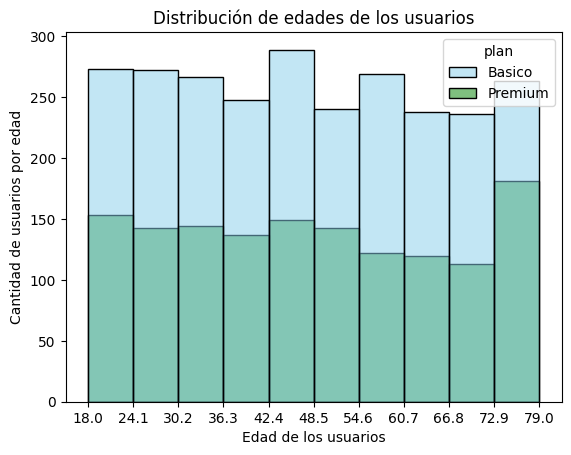

In [52]:
# Histograma para visualizar la edad (age)
minimo = user_profile["age"].min()
maximo = user_profile["age"].max()
bin_edges = np.linspace(minimo, maximo, 11)
sns.histplot(data=user_profile, x="age", hue="plan", bins=bin_edges, palette=['skyblue','green'])
plt.xticks(bin_edges)
plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios por edad')
plt.title('Distribución de edades de los usuarios')
plt.show()

💡Insights:
- Distribución de edades de los usuarios se muestra muy uniforme. Se distinguen la media (48.7) y la mediana (48.00) ambas en el mismo intervalo entre 42.4 y 48.5,en este grupo los usuarios con plan "Premium" y "Básico", se distribuyen en aproxiamdamente 50% y 50% en cada plan, aunque visualmente no es muy confiable. También se distingue una cantidad alta de usuarios entre los 18 a 24 años, cuyo plan ("premium" y "básico"), muestra tendencias similares, un poco más usuarios con "premium", pero no significativo. El grupo de mayor edad entre 73 a 79 años son los que más tienen un plan "Premium". Respecto al resto de los grupos de edad, corresponden a la mayoría de usuarios con ese tipo de plan ("Premium").

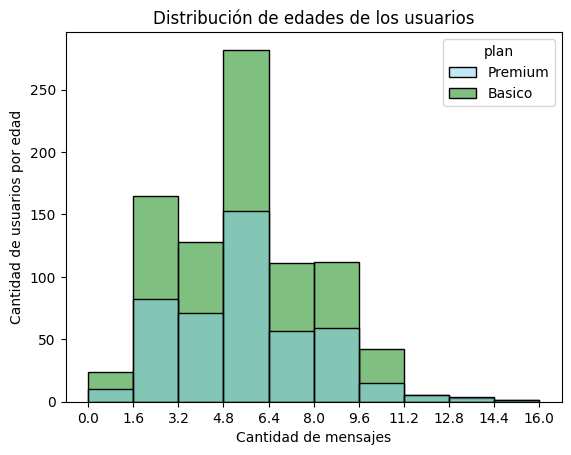

In [ ]:
# Histograma para visualizar la cant_mensajes
minimo = user_profile["cant_mensajes"].min()
maximo = user_profile["cant_mensajes"].max()
bin_edges = np.linspace(minimo, maximo, 11)
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", bins=bin_edges, palette=['skyblue','green'])
plt.xticks(bin_edges)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios por edad')
plt.title('Distribución de edades de los usuarios')
plt.show()

💡Insights:
 - La distribución general se puede considerar simétrica, normal, la media y mediana se localizan en el mismo intervalo (4.8-6,4).  Se distingue la mayoría de los usuarios que usaron mensajes, realizó de 4.8 a 6.4 mensajes, de los cuales aproximadamente 50% eran "Premium"y plan "Básico"  50% . Se deberá realizar una revisión posterior de esta tendencia.

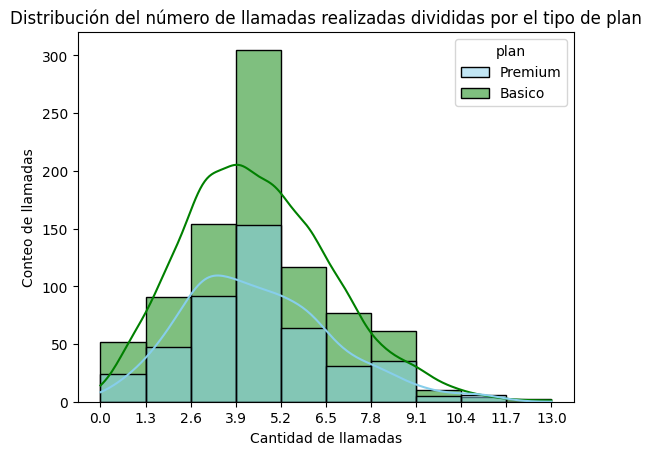

In [ ]:
# Histograma para visualizar la cant_llamadas
minimo = user_profile["cant_llamadas"].min()
maximo = user_profile["cant_llamadas"].max()
bin_edges = np.linspace(minimo, maximo, 11)
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", bins=bin_edges, palette=['skyblue','green'], kde=True)
plt.xticks(bin_edges)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Conteo de llamadas')
plt.title('Distribución del número de llamadas realizadas divididas por el tipo de plan')
plt.show()

💡Insights:
- Distribución de cantidad de llamadas se muestra simétrica, normal, la media () y la mediana se encuentran en el mismo intervalo, 3.9 - 5.2 llamadas. El usuarios con plan "premium" y "básico" realizaron aproxiamdamente, en promedio el mismo número de llamadas al observarse la distribución por tipo de plan en cada segmento.

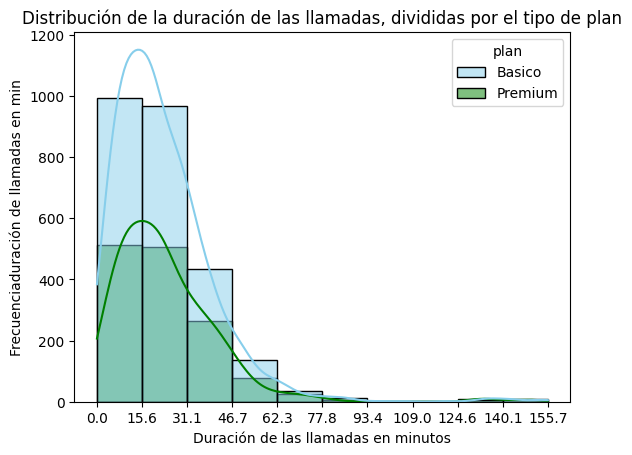

In [53]:

# Histograma para visualizar la cant_minutos_llamada
minimo = user_profile["cant_minutos_llamada"].min()
maximo = user_profile["cant_minutos_llamada"].max()
bin_edges = np.linspace(minimo, maximo, 11)
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", bins=bin_edges, palette=['skyblue','green'], kde=True)
plt.xticks(bin_edges)
plt.xlabel('Duración de las llamadas en minutos')
plt.ylabel('Frecuenciaduración de llamadas en min')
plt.title('Distribución de la duración de las llamadas, divididas por el tipo de plan')
plt.show()

💡Insights:
- La distribución de duración de las llamadas obedece a un patrón esperado, donde la mayoría de los usuarios realizaron llamadas con una duración de entre 15.6 a 31.1 minutos, rango correspondiente a la media y mediana. El decaimiento exponencial negativo en la duración de las llamadas, muestra algo natural en este tipo de sistemas, donde se espera que llamadas de muy larga duración a más de 2 desviaciones estándar de la media, sean las menos frecuentes, como se observa en la gráfica. El mismo comportamiento lo presentan tanto usuarios de plan "Premium" como los del plan "Básico" en igual proporciones (aproximadamente), lo que se verifica en las curvas de ajuste respectivas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usar **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crear un **for** para generar los 4 boxplots automáticamente.

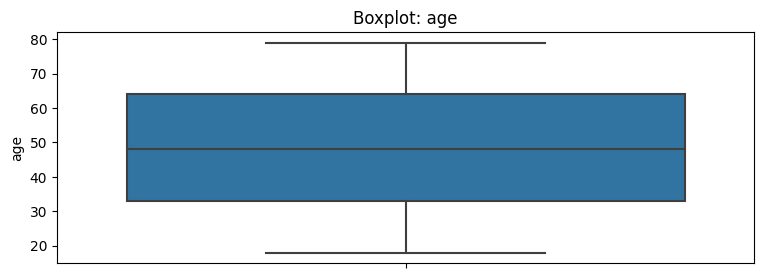

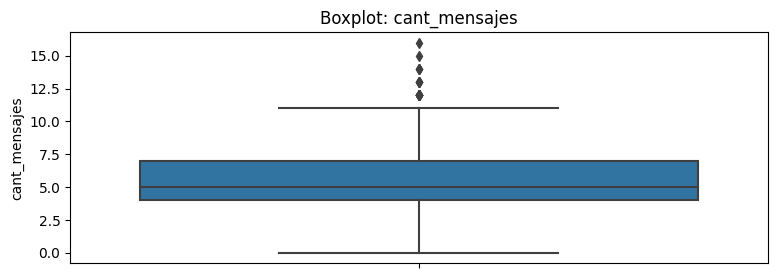

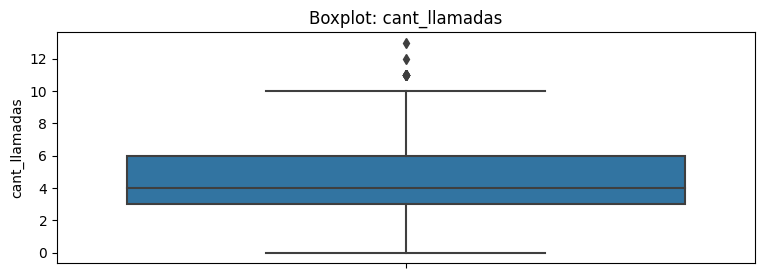

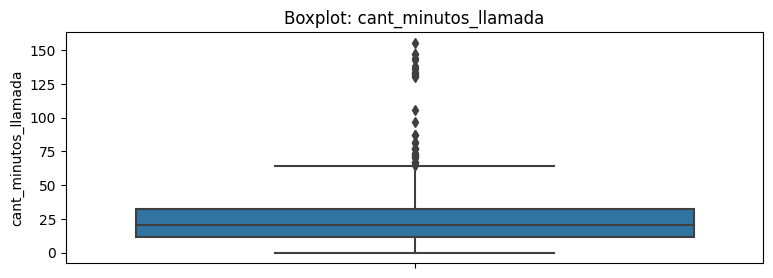

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

In [55]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    atip_val=((user_profile[col] > upper) | (user_profile[col] < lower)).sum()  #cuenta total de outliers
    above=(user_profile[col] > upper).sum()     #cuenta el total de valores mayores a Q3
    under=(user_profile[col] < lower).sum()     #cuenta el total de valores menores a Q1
    print(col, "IQR: ", IQR)
    print(col, "presenta:", atip_val, "valores atípicos")
    print(col, "tiene",under, "outliers menores al Q1, y", above, "por encima del Q3")



age IQR:  30.0
age presenta: 0 valores atípicos
age tiene 0 outliers menores al Q1, y 0 por encima del Q3
cant_mensajes IQR:  3.0
cant_mensajes presenta: 46 valores atípicos
cant_mensajes tiene 0 outliers menores al Q1, y 46 por encima del Q3
cant_llamadas IQR:  3.0
cant_llamadas presenta: 30 valores atípicos
cant_llamadas tiene 0 outliers menores al Q1, y 30 por encima del Q3
cant_minutos_llamada IQR:  20.295
cant_minutos_llamada presenta: 109 valores atípicos
cant_minutos_llamada tiene 0 outliers menores al Q1, y 109 por encima del Q3


In [56]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no

user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
    - se presentan 46 outliers, los cuales deben mantenerse. No presenta registros atípicos debajo del Q1, y todos por arriba del Q3, permite detectar qué tan frecuente ocurren registros con valores altos.
- cant_llamadas: mantener o no outliers, porqué?
  - se presenta 30 valores atípicos, todos mayores al Q3. Muestra casos reales. Se conservan sin tratamiento, dan información acerca de negocio cunándo y con qué frecuencia se pueden presentar casos extremos y sus valores.
- cant_minutos_llamada: mantener o no outliers, porqué?
  - se presentan 109 casos atípicos mayores al Q3. Por el tipo de Distribución que presenta la duración de las llamadas, se deben conservar estos valores ya que forman parte natural del comportamiento.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crear una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- A partir del uso comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [64]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where(
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5), "Bajo uso",
        np.where((user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10), "Uso medio", "Alto uso"))

In [62]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crear una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usar comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [61]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    (user_profile["age"] < 30), "Joven", np.where((user_profile["age"] < 60), "Adulto", "Adulto Mayor"))

In [58]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crear dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agregar título y etiquetas a los ejes en cada gráfico.

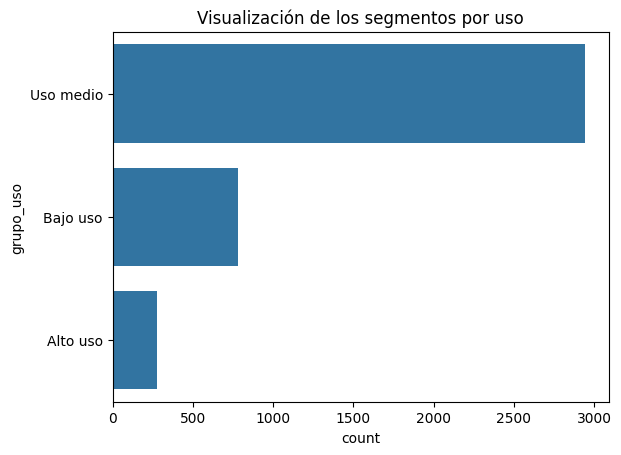

In [65]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, y='grupo_uso', order=user_profile['grupo_uso'].value_counts().index)
plt.title('Visualización de los segmentos por uso')
plt.show()

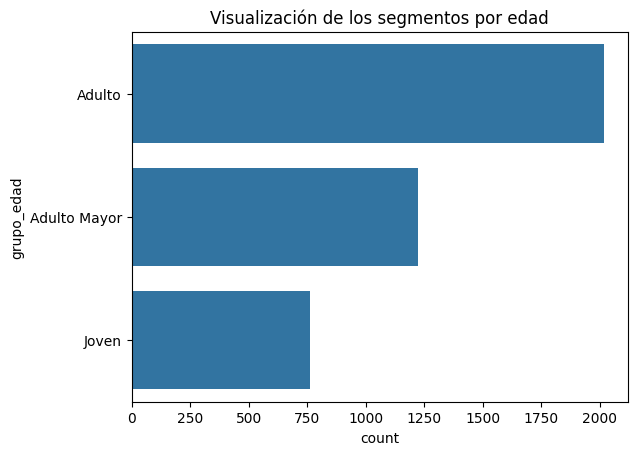

In [66]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, y="grupo_edad", order=user_profile['grupo_edad'].value_counts().index)
plt.title('Visualización de los segmentos por edad')
plt.show()

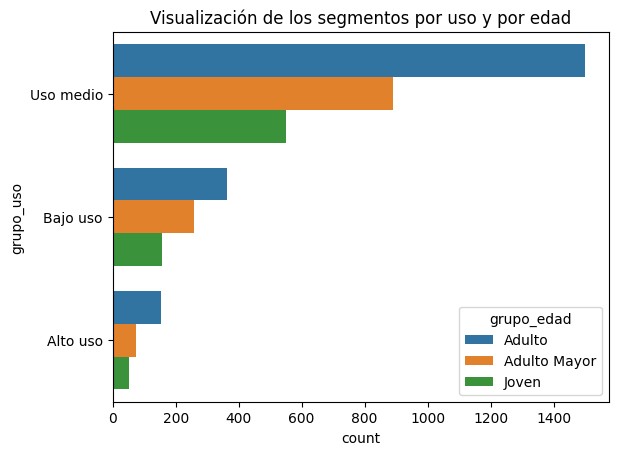

In [67]:
# Visualización de los segmentos por uso comparado con grupo de edad
sns.countplot(data=user_profile, y='grupo_uso',hue='grupo_edad' , order=user_profile['grupo_uso'].value_counts().index)
plt.title('Visualización de los segmentos por uso y por edad')
plt.show()

### Visualización de los segmentos por edad

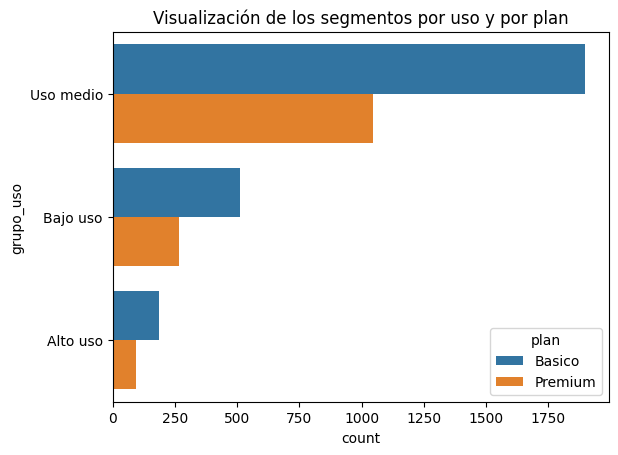

In [68]:
# Visualización de los segmentos por uso comparado con grupod de edad
sns.countplot(data=user_profile, y='grupo_uso',hue='plan' , order=user_profile['grupo_uso'].value_counts().index)
plt.title('Visualización de los segmentos por uso y por plan')
plt.show()

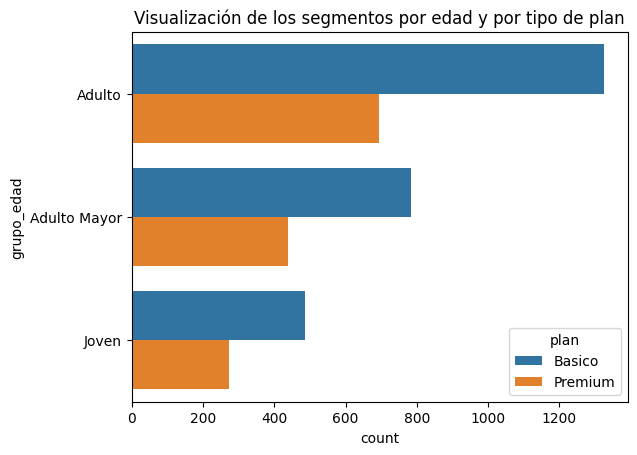

In [69]:
#visualización de cada segmento de edad , según su tipo de plan
sns.countplot(data=user_profile, y="grupo_edad", hue="plan", order=user_profile['grupo_edad'].value_counts().index)
plt.title('Visualización de los segmentos por edad y por tipo de plan')
plt.show()

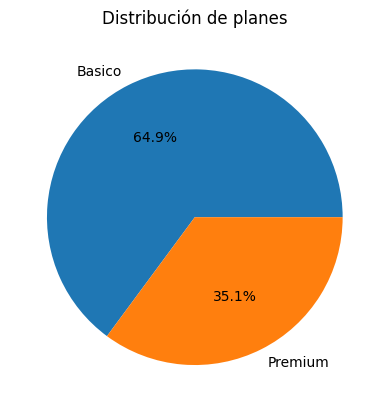

In [70]:
#gráfica de pie para identificar las proporciones del tipo de plan en total
conteo_plan= user_profile["plan"].value_counts()
conteo_plan.plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribución de planes")
plt.ylabel("")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se identificaron datos faltantes en los Datasets:
- para **plans**, con 8 columnas y dos filas no se detectaron problemas en los datos.
- para **users**, la columna "City" con 54 datos faltantes, un 11.72% de los registros.
- para **usage**, la columna  "Date" con 50 datos faltantes, representando un 0.125 % de los registros  


🔍 **Segmentos por Edad**
- El segmento más numeroso es de "Adultos", entre 30 a 60 años, su tipo de uso es "uso medio" con plan "Básico"
- Seguido por el grupo de "Adulto Mayor", mayores de 60 años, con el tipod e uso "uso medio".
- el semgmento "Joven" es el que presenta menos usuarios. Tipo de uso es "uso medio". con plan "Básico"


📊 **Segmentos por Nivel de Uso**
- El segmento más frecuente es el de consumo "uso medio" casi en 3 veces más que el siguiente nivel de consumo "Bajo" y por más de 5 veces del consumo "Alto".
- Esta tendencia es consistente en los tres para los tres segmentos de edades, "Medio" seguido de "Bajo" y finalmente "Alto".
- Para los tres segmentos de nivel de uso el tipo de plan fue más del 60% "Básico" por segmento y el resto presentó suscripciones en plan "Básico".
- A través del histograma, se pudo distinguir que el grupo de 72 años a 79 ocupaba en su mayoría el plan "Premium".

➡️ Esto sugiere que las campañas se impulsen en los segmentos de Adultos, y en el tipo de uso "medio",la población de usuarios más numerosa, que corresponden al grupo de más interés para ConnectaTel.

💡 **Recomendaciones**
- En las poblaciones jóvenes más rezagadas, de 24 a 30 años, promover una estrategia de markerting para captar más usuarios en ese segmento, que al mediano plazo pasarán a formar parte del segmento Adulto
- Los usuarios de uso Medio, los esfuerzos deben orientarse para migrarlos a plan de uso "Premium".
- Analizar el segmento de edad Adulto mayor, de entre 72 a 79 años, para "contagiar" su modelo a la población inmediata inferior, para que migren a plan "Premium" desde los 60 años en adelante
- si el tipo de uso, es más rentable si es Alto, impulsar en el segmento Adulto el aumento en el us del servicio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`